In [22]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "loan_approval_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "architsharma01/loan-approval-prediction-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1406/3019426461.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'loan-approval-prediction-dataset' dataset.
First 5 records:    loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   1240000

In [23]:
#descriptive statistics
print(df.describe())

           loan_id   no_of_dependents   income_annum   loan_amount  \
count  4269.000000        4269.000000   4.269000e+03  4.269000e+03   
mean   2135.000000           2.498712   5.059124e+06  1.513345e+07   
std    1232.498479           1.695910   2.806840e+06  9.043363e+06   
min       1.000000           0.000000   2.000000e+05  3.000000e+05   
25%    1068.000000           1.000000   2.700000e+06  7.700000e+06   
50%    2135.000000           3.000000   5.100000e+06  1.450000e+07   
75%    3202.000000           4.000000   7.500000e+06  2.150000e+07   
max    4269.000000           5.000000   9.900000e+06  3.950000e+07   

         loan_term   cibil_score   residential_assets_value  \
count  4269.000000   4269.000000               4.269000e+03   
mean     10.900445    599.936051               7.472617e+06   
std       5.709187    172.430401               6.503637e+06   
min       2.000000    300.000000              -1.000000e+05   
25%       6.000000    453.000000               2.20000

In [24]:
#descriptive statistics
df.describe().round(2)

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.0,4269.0,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.0,2.5,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.5,1.7,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.0,0.0,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.0,1.0,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.0,3.0,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.0,4.0,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.0,5.0,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [25]:
#descriptive statistics

df.groupby(' loan_status').describe().round(2)
# Transpose so variables are rows and stats are columns, grouped by loan status
df.groupby(' loan_status')[[' no_of_dependents', ' income_annum', ' loan_amount',
                            ' loan_term', ' cibil_score', ' residential_assets_value',
                            ' commercial_assets_value', ' luxury_assets_value',
                            ' bank_asset_value']].mean().round(2).T

grouped = df.groupby(' loan_status')[[' no_of_dependents', ' income_annum', ' loan_amount',
                                      ' loan_term', ' cibil_score', ' residential_assets_value',
                                      ' commercial_assets_value', ' luxury_assets_value',
                                      ' bank_asset_value']].mean().round(2).T

grouped['Difference'] = grouped[' Approved'] - grouped[' Rejected']

grouped.round(2)


loan_status,Approved,Rejected,Difference
no_of_dependents,2.47,2.54,-0.07
income_annum,5025903.61,5113825.17,-87921.56
loan_amount,15247251.51,14946063.24,301188.27
loan_term,10.40,11.73,-1.33
cibil_score,703.46,429.47,273.99
residential_assets_value,7399811.75,7592498.45,-192686.70
commercial_assets_value,5001355.42,4926720.40,74635.02
luxury_assets_value,15016603.92,15306943.58,-290339.66
bank_asset_value,4959525.60,5004959.70,-45434.10


In [26]:
# How many observations in each loan_status category
print(df[' loan_status'].value_counts())

# Shape of the dataset (rows, columns)
print(df.shape)

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
(4269, 13)


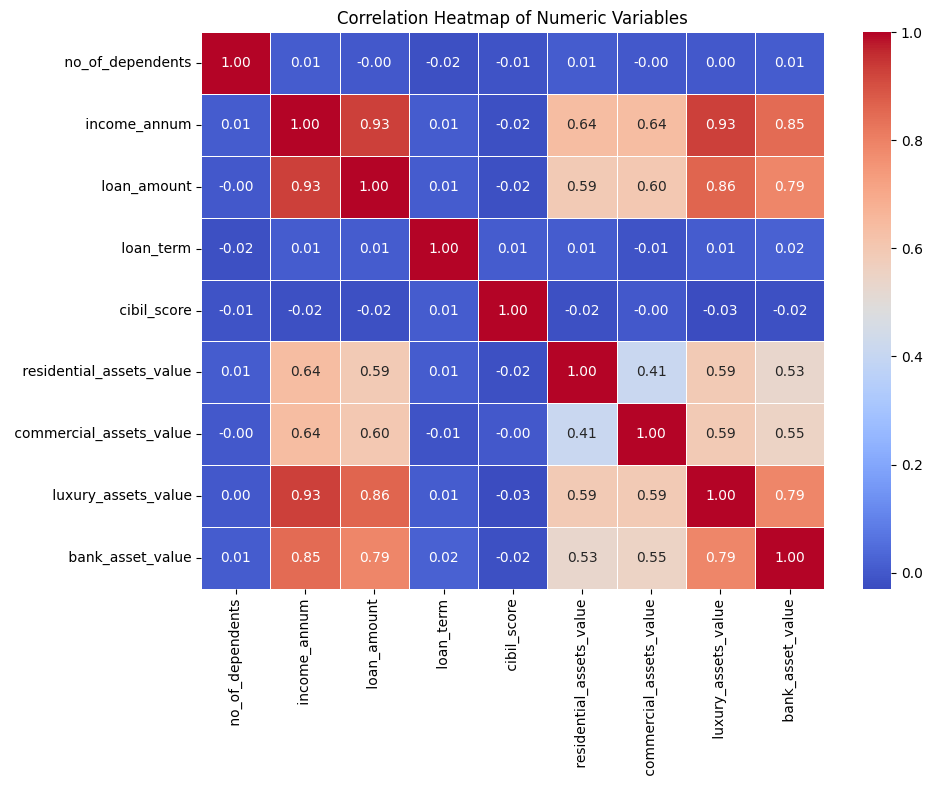

In [27]:
#correlation heatmap

import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [' no_of_dependents', ' income_annum', ' loan_amount', ' loan_term',
                ' cibil_score', ' residential_assets_value', ' commercial_assets_value',
                ' luxury_assets_value', ' bank_asset_value']

corr_matrix = df[numeric_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

In [28]:
#removing unwanted loan_id column

df_reduced = df.drop(columns=['loan_id'])
df_reduced

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [29]:
print(df.dtypes)        # shows you the data type of every column
print(df.isnull().sum())  # shows you how many missing values are in each column

loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


In [30]:
#encoding only the categorical variables we are keeping
df_encoded = pd.get_dummies(
    df_reduced,
    columns=[' education', ' self_employed', ' loan_status'],
    drop_first=True
).astype(int)

df_encoded

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes,loan_status_ Rejected
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,0,0
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,1,1
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0,1
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0,1
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1000000,2300000,12,317,2800000,500000,3300000,800000,0,1,1
4265,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,1,0
4266,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1,0,1
4267,1,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,0,0


In [31]:
print(df_encoded.dtypes)

no_of_dependents            int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
education_ Not Graduate     int64
self_employed_ Yes          int64
loan_status_ Rejected       int64
dtype: object


In [32]:
# defining inputs and output for out logistic regression
X = df_encoded.drop(columns=[' loan_status_ Rejected'])
y = df_encoded[' loan_status_ Rejected']


# Add a constant (intercept) term
X = sm.add_constant(X)

# Fit the logit model
model = sm.Logit(y, X)
result = model.fit()

# View results
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.219924
         Iterations 8
                             Logit Regression Results                             
Dep. Variable:      loan_status_ Rejected   No. Observations:                 4269
Model:                              Logit   Df Residuals:                     4257
Method:                               MLE   Df Model:                           11
Date:                    Thu, 16 Jul 2026   Pseudo R-squ.:                  0.6683
Time:                            21:23:08   Log-Likelihood:                -938.86
converged:                           True   LL-Null:                       -2830.3
Covariance Type:                nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        11.3077      0.43

In [33]:
#average marginal effects
ame = result.get_margeff(at='overall')
print(ame.summary())

          Logit Marginal Effects         
Dep. Variable:      loan_status_ Rejected
Method:                              dydx
At:                               overall
                               dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
 no_of_dependents             0.0012      0.002      0.510      0.610      -0.003       0.006
 income_annum              4.138e-08   5.96e-09      6.945      0.000    2.97e-08    5.31e-08
 loan_amount               -9.76e-09   1.18e-09     -8.298      0.000   -1.21e-08   -7.45e-09
 loan_term                    0.0102      0.001     14.778      0.000       0.009       0.012
 cibil_score                 -0.0017   3.52e-06   -475.731      0.000      -0.002      -0.002
 residential_assets_value -1.971e-10   8.01e-10     -0.246      0.806   -1.77e-09    1.37e-09
 commercial_assets_value  -1.283e-09   1.16e-09     -1.102      0.271   -3.57e-0

In [34]:
#marginal effects at the mean
mem = result.get_margeff(at='mean')
print(mem.summary())

          Logit Marginal Effects         
Dep. Variable:      loan_status_ Rejected
Method:                              dydx
At:                                  mean
                               dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
 no_of_dependents             0.0022      0.004      0.510      0.610      -0.006       0.011
 income_annum              7.492e-08   1.14e-08      6.596      0.000    5.27e-08    9.72e-08
 loan_amount              -1.767e-08    2.3e-09     -7.685      0.000   -2.22e-08   -1.32e-08
 loan_term                    0.0185      0.001     12.482      0.000       0.016       0.021
 cibil_score                 -0.0030      0.000    -23.187      0.000      -0.003      -0.003
 residential_assets_value -3.569e-10   1.45e-09     -0.246      0.806    -3.2e-09    2.48e-09
 commercial_assets_value  -2.323e-09   2.11e-09     -1.100      0.271   -6.46e-0

In [35]:
y_logit = (df[' loan_status'].str.strip() == 'Rejected').astype(int)

X_logit = pd.get_dummies(
    df[[' no_of_dependents', ' education', ' self_employed', ' income_annum',
        ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value',
        ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']],
    columns=[' education', ' self_employed'],
    drop_first=True
).astype(int)

X_logit = sm.add_constant(X_logit)

In [36]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_no_const = X_logit.drop(columns='const')

vif_data = pd.DataFrame()
vif_data['Variable'] = X_no_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_no_const.values, i)
                   for i in range(X_no_const.shape[1])]

vif_data.sort_values('VIF', ascending=False).round(2)

,Variable,VIF
1,income_annum,74.42
7,luxury_assets_value,27.54
2,loan_amount,27.25
8,bank_asset_value,12.16
4,cibil_score,6.46
3,loan_term,3.98
5,residential_assets_value,3.91
6,commercial_assets_value,3.88
0,no_of_dependents,2.87
10,self_employed_ Yes,1.94


Optimization terminated successfully.
         Current function value: 0.216897
         Iterations 9
              precision    recall  f1-score   support

    Approval       0.94      0.93      0.94       521
   Rejection       0.89      0.91      0.90       333

    accuracy                           0.92       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.92      0.92      0.92       854



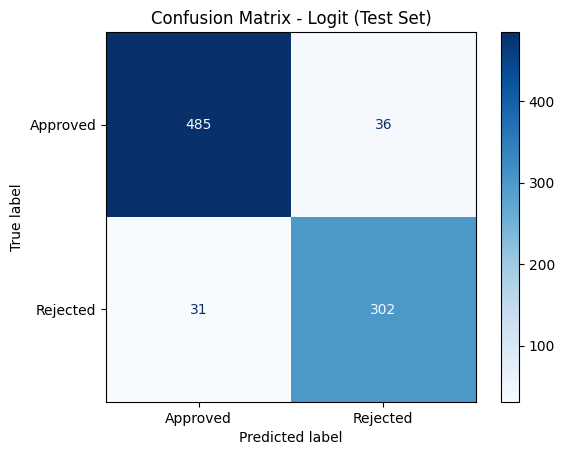

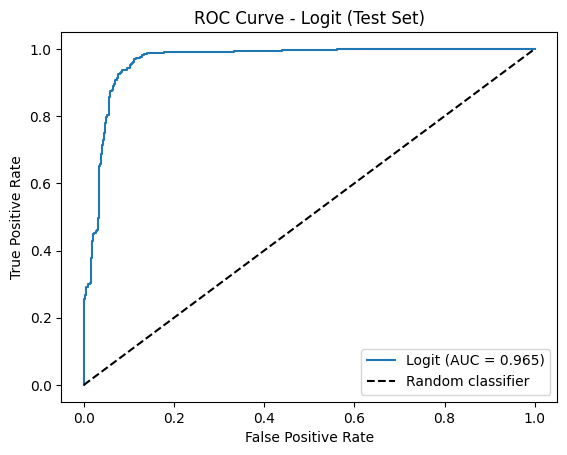

Optimization terminated successfully.
         Current function value: 0.219924
         Iterations 8


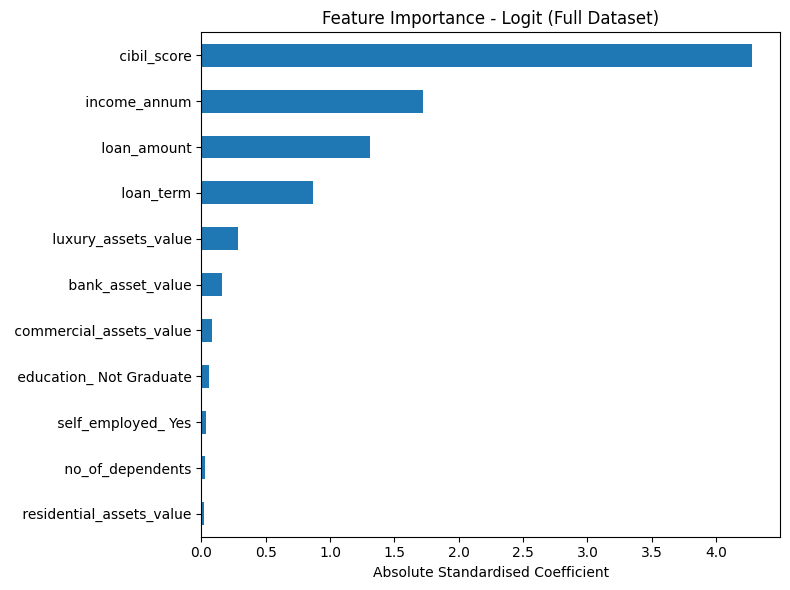

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score)
import statsmodels.api as sm

# ── 1. Train/test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1  # match your random forest seed
)

# ── 2. Fit logit on training data only ───────────────────────────────────────
logit_model = sm.Logit(y_train, X_train).fit()

# ── 3. Predict on test data ───────────────────────────────────────────────────
y_pred_prob = logit_model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# ── 4. Classification report ──────────────────────────────────────────────────
print(classification_report(
    y_test, y_pred,
    target_names=['Approval', 'Rejection']
))

# ── 5. Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Approved', 'Rejected'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logit (Test Set)')
plt.show()

# ── 6. ROC curve ──────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, label=f'Logit (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logit (Test Set)')
plt.legend()
plt.show()

# ── 7. Feature importance (full dataset — see reasoning above) ────────────────
full_model = sm.Logit(y, X).fit()
params = full_model.params.drop('const')
X_no_const = X.drop(columns='const')

std_coeffs = params * X_no_const.std()
std_coeffs_sorted = std_coeffs.abs().sort_values(ascending=True)

std_coeffs_sorted.plot(kind='barh', figsize=(8, 6))
plt.xlabel('Absolute Standardised Coefficient')
plt.title('Feature Importance - Logit (Full Dataset)')
plt.tight_layout()
plt.show()

In [38]:
# Get predicted probabilities, then classify at 0.5 threshold
y_pred_prob = result.predict(X)
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = (y_pred == y).mean()
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9190


In [39]:
# Full model (what you already have)
full_model = sm.Logit(y, X).fit()

# Restricted model with only the 4 significant regressors + constant
X_restricted = X[['const', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score']]
restricted_model = sm.Logit(y, X_restricted).fit()

# Likelihood ratio test
lr_stat = 2 * (full_model.llf - restricted_model.llf)
df_diff = full_model.df_model - restricted_model.df_model

from scipy import stats
p_value = stats.chi2.sf(lr_stat, df_diff)

print(f"LR statistic: {lr_stat:.3f}, df: {df_diff}, p-value: {p_value:.4f}")

Optimization terminated successfully.
         Current function value: 0.219924
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.220887
         Iterations 8
LR statistic: 8.221, df: 7.0, p-value: 0.3135
